# Simulation Studies

This notebook has two goals:

1. walk through a few representative simulation examples so readers can see how the MetVAE workflow behaves under different data-generating settings, and
2. reproduce the summary visualizations that compare methods across the larger simulation grid.

To keep the notebook easier to follow, the repeated simulation code is organized into a few helper functions first, and then reused across the four example scenarios.

In [1]:
import itertools
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from matplotlib.ticker import FixedLocator, FormatStrFormatter

from metvae.model import MetVAE, _simple_inference
from metvae.sim import sim_data

## 1. Helper functions used throughout the notebook

The next cell collects the repeated logic for simulation, model fitting, and performance evaluation. Defining these helpers once makes the example sections shorter and helps readers focus on what changes from one scenario to the next.

In [2]:
def simulate_metabolomics_dataset(n, d, zero_prop, seed, with_confounders):
    cor_pairs = int(0.2 * d)
    mu = list(range(10, 15))
    da_prop = 0.1

    np.random.seed(seed)

    smd = None
    sim_kwargs = {
        'n': n,
        'd': d,
        'cor_pairs': cor_pairs,
        'mu': mu,
        'da_prop': da_prop,
    }

    if with_confounders:
        smd = pd.DataFrame(
            {
                'x1': np.random.randn(n),
                'x2': np.random.choice(['a', 'b'], size=n, replace=True),
            },
            index=[f's{i}' for i in range(n)],
        )
        sim_kwargs.update({'x': smd, 'cont_list': ['x1'], 'cat_list': ['x2']})

    sim = sim_data(**sim_kwargs)
    y = sim['y']
    true_cor = sim['cor_matrix']

    log_y = np.log(y)
    log_sample_bias = np.log(np.random.uniform(1e-3, 1e-1, size=n))
    log_feature_bias = np.log(np.random.uniform(1e-1, 1, size=d))
    log_data = log_y + log_sample_bias[:, np.newaxis]
    log_data = log_data + log_feature_bias.reshape(1, d)
    data = np.exp(log_data)

    thresholds = np.quantile(data, zero_prop, axis=0)
    data_miss = np.where(data < thresholds, 0, data)
    data_miss = pd.DataFrame(data_miss, index=y.index, columns=y.columns)

    return {
        'data': data_miss,
        'meta': smd,
        'true_cor': true_cor,
        'sim': sim,
    }

def fit_metvae_model(data, meta, n, d):
    model_kwargs = {
        'data': data,
        'features_as_rows': False,
        'meta': meta,
        'continuous_covariate_keys': ['x1'] if meta is not None else None,
        'categorical_covariate_keys': ['x2'] if meta is not None else None,
        'latent_dim': min(n, d),
    }

    if meta is None:
        model_kwargs['feature_zero_threshold'] = None

    model = MetVAE(**model_kwargs)
    model.train(
        batch_size=100,
        num_workers=0,
        max_epochs=1000,
        learning_rate=1e-2,
        log_every_n_steps=1,
    )
    return model

def summarize_sparse_estimate(est_cor, true_cor):
    est_values = est_cor.values if isinstance(est_cor, pd.DataFrame) else est_cor
    true_idx = true_cor[np.tril_indices_from(true_cor, k=-1)] != 0
    est_idx = est_values[np.tril_indices_from(est_values, k=-1)] != 0
    tpr = np.sum(est_idx & true_idx) / np.sum(true_idx)
    fpr = np.sum(est_idx & ~true_idx) / np.sum(~true_idx)
    fdr = np.sum(est_idx & ~true_idx) / np.sum(est_idx)
    return {'tpr': tpr, 'fpr': fpr, 'fdr': fdr}

def print_metrics(label, metrics, extra=None):
    print(f"{label}: tpr = {metrics['tpr']}, fpr = {metrics['fpr']}, fdr = {metrics['fdr']}")
    if extra is not None:
        print(extra)

def run_pvalue_pipeline(model, true_cor, cutoff=0.05):
    model.get_corr(num_sim=100)
    results_metvae = model.sparse_by_p(p_adj_method='fdr_bh', cutoff=cutoff)
    metrics = summarize_sparse_estimate(results_metvae['sparse_estimate'], true_cor)
    return results_metvae, metrics

def run_sec_fixed_rho(model, true_cor, rho=2.2):
    results_metvae = model.sparse_by_sec(rho=rho)
    metrics = summarize_sparse_estimate(results_metvae['sparse_estimate'], true_cor)
    return results_metvae, metrics

def run_sec_grid_search(model, true_cor, c_grid=tuple(float(x) for x in range(8, 16))):
    results_metvae = model.sparse_by_sec(c_grid=c_grid)
    metrics = summarize_sparse_estimate(results_metvae['sparse_estimate'], true_cor)
    return results_metvae, metrics

## 2. Four representative simulation examples

The examples below all use the same basic simulation workflow, but vary along two axes:

- whether confounders are present, and
- whether zero inflation is present.

Within each example, we fit MetVAE once and then compare two sparsification strategies:

- p-value filtering, and
- SEC, shown with both a fixed `rho` and a grid-based search.

### Example 1: no confounders, with zeros

This first example is the simplest sparse setting: no covariates are adjusted for, but the observed abundance table contains zeros introduced by censoring.

In [3]:
n, d, zero_prop, seed = 100, 500, 0.3, 24

example_1 = simulate_metabolomics_dataset(
    n=n,
    d=d,
    zero_prop=zero_prop,
    seed=seed,
    with_confounders=False,
)

model = fit_metvae_model(example_1['data'], example_1['meta'], n=n, d=d)
true_cor = example_1['true_cor']

Start: samples=100, features=500
Filtered samples: none (no sample_zero_threshold provided)
After zero filtering: samples=100, features=500
Post-cleaning (convert negative values to zeros and drop all-zero samples): samples=100, features=500


/var/folders/rn/10vtwtd944j73gfdxc_pbl680000gr/T/ipykernel_26180/2820156517.py:63: UserWarning: train() ignores the extra keyword arguments ['log_every_n_steps'].
  model.train(


  0%|          | 0/1000 [00:00<?, ?it/s]

  2%|▏         | 16/1000 [00:00<00:06, 156.03it/s]

  3%|▎         | 34/1000 [00:00<00:05, 167.35it/s]

...

 91%|█████████ | 907/1000 [00:04<00:00, 215.55it/s]

 93%|█████████▎| 931/1000 [00:04<00:00, 220.98it/s]

 96%|█████████▌| 955/1000 [00:04<00:00, 225.31it/s]

 98%|█████████▊| 978/1000 [00:04<00:00, 226.39it/s]

100%|██████████| 1000/1000 [00:04<00:00, 227.56it/s]

#### P-value filtering

We first estimate the correlation matrix through repeated imputations and then apply the p-value-based sparsification rule.

In [4]:
results_metvae, metrics = run_pvalue_pipeline(model, true_cor)
print_metrics('P-value filtering', metrics)

P-value filtering: tpr = 0.92, fpr = 5.615724027276374e-05, fdr = 0.0707070707070707


#### SEC

We then evaluate SEC twice: once with a fixed `rho` and once with a small grid search that reports the selected value.

In [5]:
results_metvae, metrics = run_sec_fixed_rho(model, true_cor, rho=2.2)
print_metrics('SEC (fixed rho)', metrics)

SEC (fixed rho): tpr = 0.9, fpr = 4.0112314480545525e-05, fdr = 0.05263157894736842


In [6]:
results_metvae, metrics = run_sec_grid_search(model, true_cor, c_grid=tuple(float(x) for x in range(8, 16)))
print_metrics('SEC (grid search)', metrics, extra=f"rho = {results_metvae['best_rho']}")

SEC (grid search): tpr = 0.85, fpr = 0.0, fdr = 0.0
rho = 2.7699017450199266


### Example 2: no confounders, without zeros

This example isolates the effect of removing zero inflation while keeping the rest of the setup unchanged.

In [7]:
n, d, zero_prop, seed = 100, 500, 0.0, 44

example_2 = simulate_metabolomics_dataset(
    n=n,
    d=d,
    zero_prop=zero_prop,
    seed=seed,
    with_confounders=False,
)

model = fit_metvae_model(example_2['data'], example_2['meta'], n=n, d=d)
true_cor = example_2['true_cor']

Start: samples=100, features=500
Filtered samples: none (no sample_zero_threshold provided)
After zero filtering: samples=100, features=500
Post-cleaning (convert negative values to zeros and drop all-zero samples): samples=100, features=500


/var/folders/rn/10vtwtd944j73gfdxc_pbl680000gr/T/ipykernel_26180/2820156517.py:63: UserWarning: train() ignores the extra keyword arguments ['log_every_n_steps'].
  model.train(


  0%|          | 0/1000 [00:00<?, ?it/s]

  2%|▏         | 18/1000 [00:00<00:05, 178.16it/s]

  4%|▍         | 43/1000 [00:00<00:04, 217.62it/s]

...

 91%|█████████ | 906/1000 [00:03<00:00, 249.44it/s]

 94%|█████████▍| 938/1000 [00:03<00:00, 266.81it/s]

 97%|█████████▋| 968/1000 [00:03<00:00, 275.31it/s]

100%|██████████| 1000/1000 [00:03<00:00, 287.30it/s]

100%|██████████| 1000/1000 [00:03<00:00, 250.57it/s]

#### P-value filtering

We reuse the same evaluation sequence so the only change across examples is the data-generating setting.

In [8]:
results_metvae, metrics = run_pvalue_pipeline(model, true_cor)
print_metrics('P-value filtering', metrics)

P-value filtering: tpr = 0.94, fpr = 3.208985158443642e-05, fdr = 0.04081632653061224


#### SEC

In [9]:
results_metvae, metrics = run_sec_fixed_rho(model, true_cor, rho=2.2)
print_metrics('SEC (fixed rho)', metrics)

SEC (fixed rho): tpr = 0.94, fpr = 2.4067388688327318e-05, fdr = 0.030927835051546393


In [10]:
results_metvae, metrics = run_sec_grid_search(model, true_cor, c_grid=tuple(float(x) for x in range(8, 16)))
print_metrics('SEC (grid search)', metrics, extra=f"rho = {results_metvae['best_rho']}")

SEC (grid search): tpr = 0.89, fpr = 0.0, fdr = 0.0
rho = 2.603707640318731


### Example 3: with confounders, with zeros

We now move to the covariate-adjusted setting. The simulated metadata include one continuous and one categorical confounder, and zeros are again introduced into the abundance matrix.

In [11]:
n, d, zero_prop, seed = 100, 500, 0.3, 42

example_3 = simulate_metabolomics_dataset(
    n=n,
    d=d,
    zero_prop=zero_prop,
    seed=seed,
    with_confounders=True,
)

model = fit_metvae_model(example_3['data'], example_3['meta'], n=n, d=d)
true_cor = example_3['true_cor']

Start: samples=100, features=500
Filtered features: removed 0 (threshold 0.30)
Filtered samples: none (no sample_zero_threshold provided)
After zero filtering: samples=100, features=500
Post-cleaning (convert negative values to zeros and drop all-zero samples): samples=100, features=500


/var/folders/rn/10vtwtd944j73gfdxc_pbl680000gr/T/ipykernel_26180/2820156517.py:63: UserWarning: train() ignores the extra keyword arguments ['log_every_n_steps'].
  model.train(


  0%|          | 0/1000 [00:00<?, ?it/s]

  2%|▏         | 20/1000 [00:00<00:04, 197.87it/s]

  4%|▍         | 40/1000 [00:00<00:05, 171.13it/s]

...

 94%|█████████▎| 935/1000 [00:06<00:00, 136.30it/s]

 95%|█████████▌| 951/1000 [00:06<00:00, 141.29it/s]

 97%|█████████▋| 966/1000 [00:06<00:00, 143.56it/s]

 98%|█████████▊| 984/1000 [00:06<00:00, 152.68it/s]

100%|██████████| 1000/1000 [00:06<00:00, 150.90it/s]

#### P-value filtering

In [12]:
results_metvae, metrics = run_pvalue_pipeline(model, true_cor)
print_metrics('P-value filtering', metrics)

P-value filtering: tpr = 0.73, fpr = 0.00012835940633774569, fdr = 0.1797752808988764


#### SEC

In [13]:
results_metvae, metrics = run_sec_fixed_rho(model, true_cor, rho=2.2)
print_metrics('SEC (fixed rho)', metrics)

SEC (fixed rho): tpr = 0.72, fpr = 0.00011231448054552748, fdr = 0.16279069767441862


In [14]:
results_metvae, metrics = run_sec_grid_search(model, true_cor, c_grid=tuple(float(x) for x in range(8, 16)))
print_metrics('SEC (grid search)', metrics, extra=f"rho = {results_metvae['best_rho']}")

SEC (grid search): tpr = 0.5, fpr = 0.0, fdr = 0.0
rho = 2.9083968322709226


### Example 4: with confounders, without zeros

The final example removes zero inflation from the confounded setting so readers can compare all four combinations side by side.

In [15]:
n, d, zero_prop, seed = 100, 500, 0.0, 92

example_4 = simulate_metabolomics_dataset(
    n=n,
    d=d,
    zero_prop=zero_prop,
    seed=seed,
    with_confounders=True,
)

model = fit_metvae_model(example_4['data'], example_4['meta'], n=n, d=d)
true_cor = example_4['true_cor']

Start: samples=100, features=500
Filtered features: removed 0 (threshold 0.30)
Filtered samples: none (no sample_zero_threshold provided)
After zero filtering: samples=100, features=500
Post-cleaning (convert negative values to zeros and drop all-zero samples): samples=100, features=500


/var/folders/rn/10vtwtd944j73gfdxc_pbl680000gr/T/ipykernel_26180/2820156517.py:63: UserWarning: train() ignores the extra keyword arguments ['log_every_n_steps'].
  model.train(


  0%|          | 0/1000 [00:00<?, ?it/s]

  2%|▎         | 25/1000 [00:00<00:04, 241.96it/s]

  5%|▌         | 50/1000 [00:00<00:04, 227.28it/s]

...

 92%|█████████▏| 920/1000 [00:04<00:00, 222.65it/s]

 94%|█████████▍| 943/1000 [00:04<00:00, 215.09it/s]

 97%|█████████▋| 972/1000 [00:04<00:00, 234.62it/s]

100%|██████████| 1000/1000 [00:04<00:00, 247.06it/s]

100%|██████████| 1000/1000 [00:04<00:00, 209.71it/s]

#### P-value filtering

In [16]:
results_metvae, metrics = run_pvalue_pipeline(model, true_cor)
print_metrics('P-value filtering', metrics)

P-value filtering: tpr = 0.98, fpr = 3.208985158443642e-05, fdr = 0.0392156862745098


#### SEC

In [17]:
results_metvae, metrics = run_sec_fixed_rho(model, true_cor, rho=2.2)
print_metrics('SEC (fixed rho)', metrics)

SEC (fixed rho): tpr = 0.98, fpr = 1.604492579221821e-05, fdr = 0.02


In [18]:
results_metvae, metrics = run_sec_grid_search(model, true_cor, c_grid=tuple(float(x) for x in range(8, 16)))
print_metrics('SEC (grid search)', metrics, extra=f"rho = {results_metvae['best_rho']}")

SEC (grid search): tpr = 0.94, fpr = 8.022462896109105e-06, fdr = 0.010526315789473684
rho = 2.520610587968133


## 3. Visualization setup for the full simulation benchmark

The example runs above are useful for illustrating the workflow, but the figures below summarize the larger simulation study saved as CSV files. We first define the simulation grid and a few plotting helpers, then assemble one figure for the unconfounded setting and one for the confounded setting.

### Simulation settings

In [19]:
n_vals = [100]
d_vals = [50, 200, 500]
zero_props = [0.0, 0.1, 0.2, 0.3]
iter_num = 100

simpattern = pd.DataFrame(
    list(itertools.product(n_vals, d_vals, zero_props)),
    columns=['n', 'd', 'zero_prop']
)
simpattern['setting'] = simpattern.apply(lambda r: f"{r.n}, {r.d}, {r.zero_prop}", axis=1)
facet_order = [f"N = 100, D = 50", f"N = 100, D = 200", f"N = 100, D = 500"]

def attach_method_and_setting(df: pd.DataFrame, method_name: str, cols=('tpr', 'fpr', 'fdr')) -> pd.DataFrame:
    df = df.copy()
    df.columns = list(cols)
    df['method'] = method_name
    df['setting'] = np.repeat(simpattern['setting'].values, iter_num)
    return df

### Plot helpers

These helpers reshape the benchmark summaries and create the multi-panel bar plots used for the supplementary figures.

In [20]:
def summarize_for_bars(df: pd.DataFrame):
    """Compute mean and sd per (measure, label, zero_prop, method)."""
    g = (
        df.groupby(['measure', 'label', 'zero_prop', 'method'], dropna=False, observed=True)['value']
        .agg(['mean', 'std'])
        .reset_index()
    )
    return g

def jitter_points(ax, x, y, color, alpha=0.25, width=0.04, s=8):
    """Light jitter cloud around bars for visualizing distribution."""
    if len(y) == 0:
        return
    rng = np.random.default_rng(0)
    jitter = rng.uniform(-width, width, size=len(y))
    ax.scatter(x + jitter, y, alpha=alpha, s=s, edgecolors='none', color=color)

def plot_facets(df_plot: pd.DataFrame, include_methods, title=None):
    dfp = df_plot[df_plot['method'].isin(include_methods)].copy()
    dfp['method'] = pd.Categorical(dfp['method'], categories=include_methods, ordered=True)
    dfp['label'] = pd.Categorical(dfp['label'], categories=facet_order, ordered=True)

    measures = ['tpr', 'fdr']
    labels = facet_order
    nrows, ncols = len(measures), len(labels)
    bar = summarize_for_bars(dfp)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 8), sharex=True, sharey=False)
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = axes[:, np.newaxis]

    cmap = plt.get_cmap('tab10')
    color_map = {m: cmap(i % 10) for i, m in enumerate(include_methods)}
    zp_levels = sorted(dfp['zero_prop'].dropna().unique())
    mcount = len(include_methods)
    width = 0.8 / max(mcount, 1)

    for r, measure in enumerate(measures):
        for c, lab in enumerate(labels):
            ax = axes[r, c]
            panel_sum = bar[(bar['measure'] == measure) & (bar['label'] == lab)]

            for mi, method in enumerate(include_methods):
                pm = panel_sum[panel_sum['method'] == method]

                for zi, zp in enumerate(zp_levels):
                    sub = pm[pm['zero_prop'] == zp]
                    if sub.empty:
                        continue
                    x = zi + (mi - (mcount - 1) / 2) * width
                    mean = sub['mean'].values[0]
                    sd = sub['std'].values[0]
                    ax.bar(
                        x,
                        mean,
                        width=width,
                        color=color_map[method],
                        edgecolor='black',
                        linewidth=0.5,
                        label=method if zi == 0 else None,
                    )
                    ax.errorbar(x, mean, yerr=sd, fmt='none', ecolor='black', elinewidth=0.8, capsize=3)

                for zi, zp in enumerate(zp_levels):
                    raw = dfp[
                        (dfp['measure'] == measure)
                        & (dfp['label'] == lab)
                        & (dfp['method'] == method)
                        & (dfp['zero_prop'] == zp)
                    ]['value'].dropna().values
                    x_center = zi + (mi - (mcount - 1) / 2) * width
                    jitter_points(ax, x_center, raw, color=color_map[method], alpha=0.15, width=width * 0.45, s=6)

            ax.set_xticks(range(len(zp_levels)))
            ax.set_xticklabels([f'{z:.1f}' for z in zp_levels])
            if c == 0:
                ax.set_ylabel(measure.upper())
            ax.set_title(lab)
            ax.grid(axis='y', alpha=0.25)
            ax.set_ylim(0, 1)

            base = np.arange(0.0, 1.0001, 0.2)
            ticks = np.unique(np.r_[base, 0.1])
            ax.yaxis.set_major_locator(FixedLocator(ticks))
            ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

            if measure == 'fdr':
                ax.axhline(0.1, linestyle='--', linewidth=1, color='black', alpha=0.7)

    handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[m]) for m in include_methods]
    labels = include_methods
    fig.legend(
        handles,
        labels,
        loc='lower center',
        ncol=len(labels),
        frameon=False,
        bbox_to_anchor=(0.5, -0.015),
        borderaxespad=0.0,
    )
    fig.suptitle(title, y=1.02)
    fig.supxlabel('Proportion of Zeros', y=0.02)
    return fig

## 4. Benchmark figure: simulations without confounders

We now load the saved benchmark summaries for the unconfounded simulation grid, reshape them into plotting format, and render the first supplementary figure.

### Load CSVs

In [21]:
base = '/Users/hlin1239/My Drive/Research/005_metvae/github/results/intermediate_results'
paths = {
    'MetVAE': os.path.join(base, 'sim_metvae_unconfound.csv'),
    'Pearson': os.path.join(base, 'sim_pearson_unconfound.csv'),
    'SECOM_full': os.path.join(base, 'sim_secom_unconfound.csv'),
    'SparCC': os.path.join(base, 'sim_sparcc_unconfound.csv'),
    'SPIEC-EASI': os.path.join(base, 'sim_spiec_easi_unconfound.csv'),
    'SPRING': os.path.join(base, 'sim_spring_unconfound.csv'),
}

df_metvae = pd.read_csv(paths['MetVAE']).iloc[:, [4, 5, 6]]
df_pearson = pd.read_csv(paths['Pearson'])
df_secom = pd.read_csv(paths['SECOM_full'])
df_secom1 = df_secom.iloc[:, [0, 1, 2]]
df_secom2 = df_secom.iloc[:, [3, 4, 5]]
df_sparcc = pd.read_csv(paths['SparCC'])
df_se = pd.read_csv(paths['SPIEC-EASI'])
df_spring = pd.read_csv(paths['SPRING'])

target_rows = len(simpattern) * iter_num
if len(df_sparcc) < target_rows:
    pad = pd.DataFrame(index=range(target_rows - len(df_sparcc)), columns=df_sparcc.columns)
    df_sparcc = pd.concat([df_sparcc, pad], axis=0, ignore_index=True)

df_metvae = attach_method_and_setting(df_metvae, 'MetVAE')
df_pearson = attach_method_and_setting(df_pearson, 'Pearson')
df_secom1 = attach_method_and_setting(df_secom1, 'SECOM (Filtering)')
df_secom2 = attach_method_and_setting(df_secom2, 'SECOM (Thresholding)')
df_sparcc = attach_method_and_setting(df_sparcc, 'SparCC')
df_se = attach_method_and_setting(df_se, 'SPIEC-EASI')
df_spring = attach_method_and_setting(df_spring, 'SPRING')

df_all = pd.concat([df_metvae, df_pearson, df_secom1, df_secom2, df_sparcc, df_se, df_spring], ignore_index=True)
df_all = df_all.drop(columns=['fpr'])

/var/folders/rn/10vtwtd944j73gfdxc_pbl680000gr/T/ipykernel_26180/905651844.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_sparcc = pd.concat([df_sparcc, pad], axis=0, ignore_index=True)


### Prepare for plotting

The raw benchmark tables are reshaped into a long format so the plotting helper can facet by metric, dimensionality, and zero proportion.

In [22]:
df_long = df_all.melt(
    id_vars=['method', 'setting'],
    value_vars=['tpr', 'fdr'],
    var_name='measure',
    value_name='value'
)

split = df_long['setting'].str.split(', ', expand=True)
df_long['n'] = pd.to_numeric(split[0], errors='coerce').round().astype(int)
df_long['d'] = pd.to_numeric(split[1], errors='coerce').round().astype(int)
df_long['zero_prop'] = pd.to_numeric(split[2], errors='coerce')
df_long['label'] = 'N = ' + df_long['n'].astype(str) + ', D = ' + df_long['d'].astype(str)

method_order = ['MetVAE', 'SECOM (Filtering)', 'SECOM (Thresholding)', 'SparCC', 'SPIEC-EASI', 'SPRING', 'Pearson']

### Make the figure

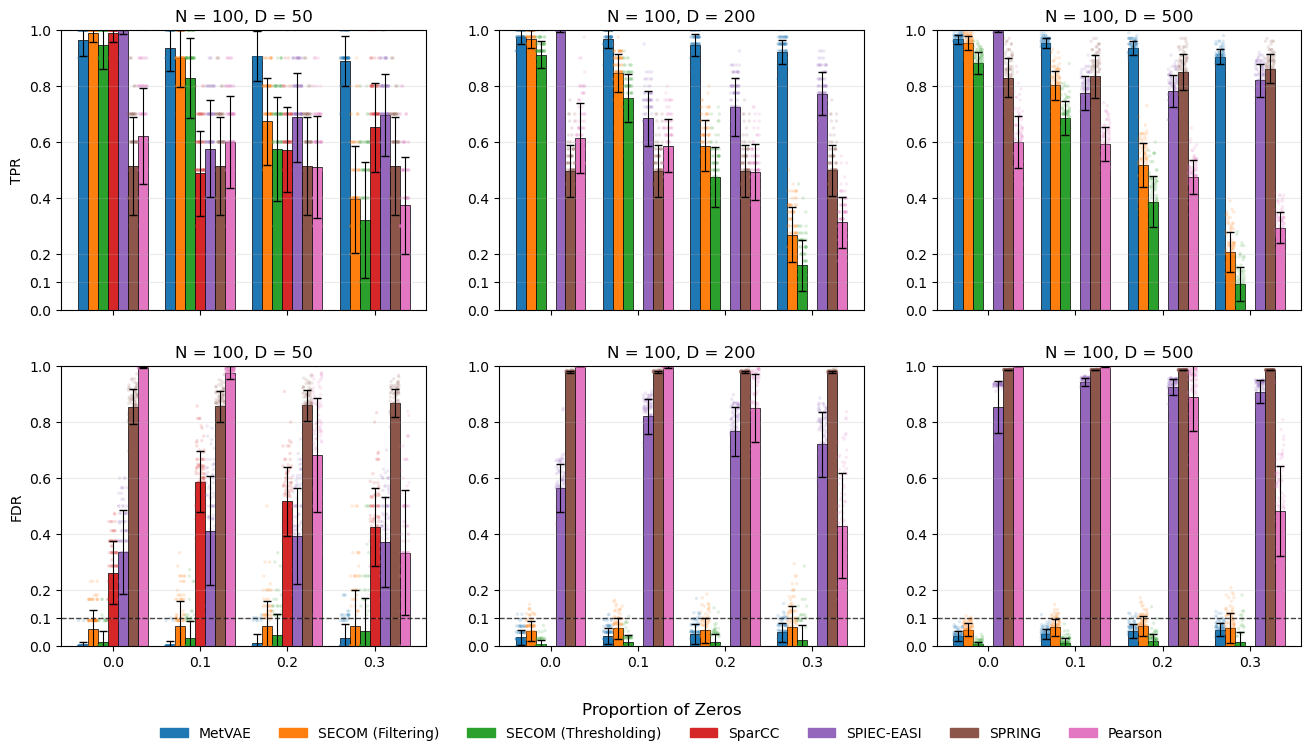

In [23]:
fig_unconfound = plot_facets(df_long, include_methods=method_order)
plt.show()

## 5. Benchmark figure: simulations with confounders

We repeat the same loading and plotting workflow for the confounded simulation benchmark.

### Load CSVs

In [24]:
base = '/Users/hlin1239/My Drive/Research/005_metvae/github/results/intermediate_results'
paths = {
    'MetVAE': os.path.join(base, 'sim_metvae_confound.csv'),
    'Pearson': os.path.join(base, 'sim_pearson_confound.csv'),
    'SECOM_full': os.path.join(base, 'sim_secom_confound.csv'),
    'SparCC': os.path.join(base, 'sim_sparcc_confound.csv'),
    'SPIEC-EASI': os.path.join(base, 'sim_spiec_easi_confound.csv'),
    'SPRING': os.path.join(base, 'sim_spring_confound.csv'),
}

df_metvae = pd.read_csv(paths['MetVAE']).iloc[:, [4, 5, 6]]
df_pearson = pd.read_csv(paths['Pearson'])
df_secom = pd.read_csv(paths['SECOM_full'])
df_secom1 = df_secom.iloc[:, [0, 1, 2]]
df_secom2 = df_secom.iloc[:, [3, 4, 5]]
df_sparcc = pd.read_csv(paths['SparCC'])
df_se = pd.read_csv(paths['SPIEC-EASI'])
df_spring = pd.read_csv(paths['SPRING'])

target_rows = len(simpattern) * iter_num
if len(df_sparcc) < target_rows:
    pad = pd.DataFrame(index=range(target_rows - len(df_sparcc)), columns=df_sparcc.columns)
    df_sparcc = pd.concat([df_sparcc, pad], axis=0, ignore_index=True)

df_metvae = attach_method_and_setting(df_metvae, 'MetVAE')
df_pearson = attach_method_and_setting(df_pearson, 'Pearson')
df_secom1 = attach_method_and_setting(df_secom1, 'SECOM (Filtering)')
df_secom2 = attach_method_and_setting(df_secom2, 'SECOM (Thresholding)')
df_sparcc = attach_method_and_setting(df_sparcc, 'SparCC')
df_se = attach_method_and_setting(df_se, 'SPIEC-EASI')
df_spring = attach_method_and_setting(df_spring, 'SPRING')

df_all = pd.concat([df_metvae, df_pearson, df_secom1, df_secom2, df_sparcc, df_se, df_spring], ignore_index=True)
df_all = df_all.drop(columns=['fpr'])

/var/folders/rn/10vtwtd944j73gfdxc_pbl680000gr/T/ipykernel_26180/296839476.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_sparcc = pd.concat([df_sparcc, pad], axis=0, ignore_index=True)


### Prepare for plotting

In [25]:
df_long = df_all.melt(
    id_vars=['method', 'setting'],
    value_vars=['tpr', 'fdr'],
    var_name='measure',
    value_name='value'
)

split = df_long['setting'].str.split(', ', expand=True)
df_long['n'] = pd.to_numeric(split[0], errors='coerce').round().astype(int)
df_long['d'] = pd.to_numeric(split[1], errors='coerce').round().astype(int)
df_long['zero_prop'] = pd.to_numeric(split[2], errors='coerce')
df_long['label'] = 'N = ' + df_long['n'].astype(str) + ', D = ' + df_long['d'].astype(str)

method_order = ['MetVAE', 'SECOM (Filtering)', 'SECOM (Thresholding)', 'SparCC', 'SPIEC-EASI', 'SPRING', 'Pearson']

### Make the figure

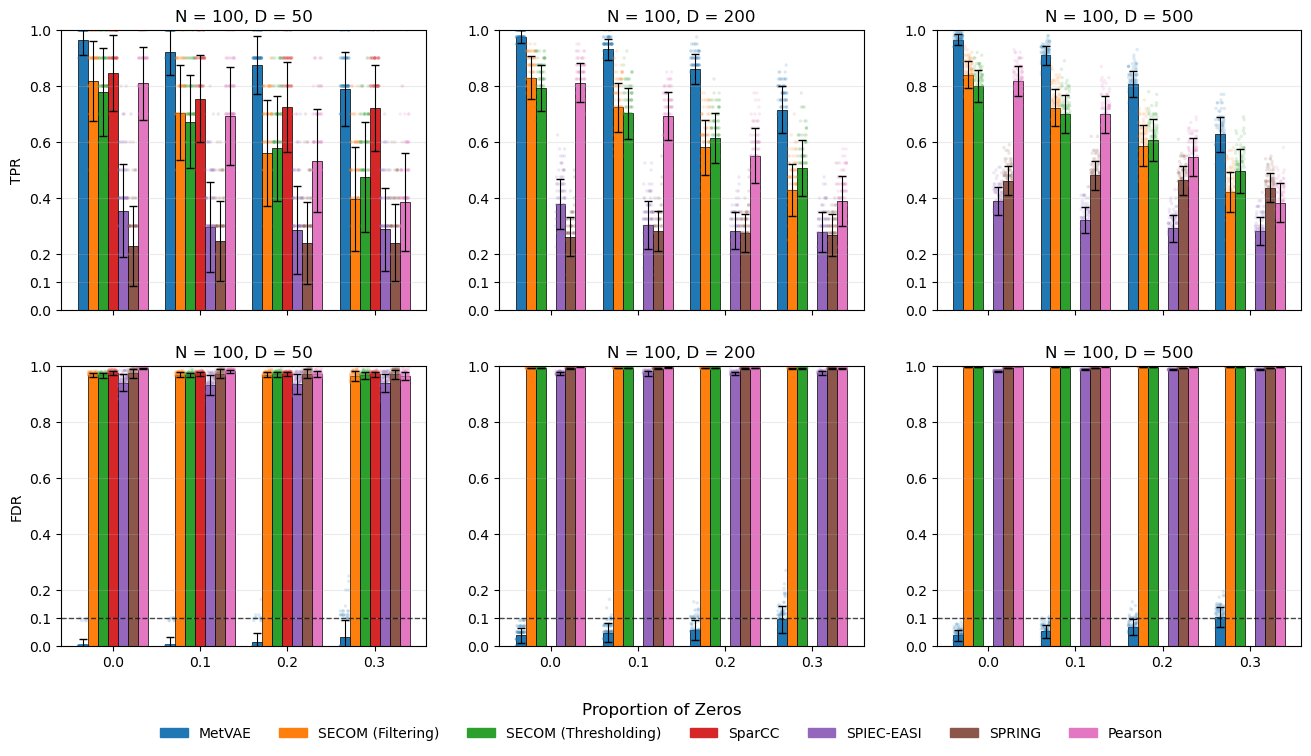

In [26]:
fig_confound = plot_facets(df_long, include_methods=method_order)
plt.show()

## 6. Save outputs

The final cell writes the two supplementary figures generated above.

In [27]:
fig_unconfound.savefig('results/figures/FigureS1.pdf', bbox_inches='tight')
fig_confound.savefig('results/figures/FigureS2.pdf', bbox_inches='tight')